Import libraries

In [75]:
import pandas as pd

In [76]:
import numpy as np

In [77]:
import matplotlib.pyplot as plt

In [78]:
import seaborn as sns

In [79]:
from sklearn.model_selection  import train_test_split

In [80]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [81]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
from sklearn.ensemble import RandomForestClassifier

In [84]:
import warnings

In [85]:
warnings.filterwarnings('ignore')

Load Data

In [86]:
df = pd.read_csv(r"C:\Users\dell\Downloads\archive (11).zip")

In [87]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic Exploration

In [88]:
df.shape

(7043, 21)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [90]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Data Cleaning

In [91]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [92]:
# Handle missing values
df = df.dropna()

In [93]:
# Drop unnecessary column
df.drop('customerID', axis=1, inplace=True)

Target Variable Encoding

In [94]:
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No': 0})

Exploratory Data Analysis (EDA)

In [95]:
# Churn Distribution

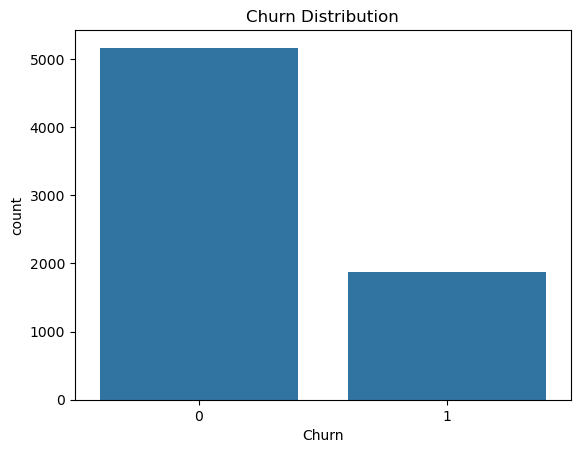

In [96]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [97]:
#Churn by Contract Type

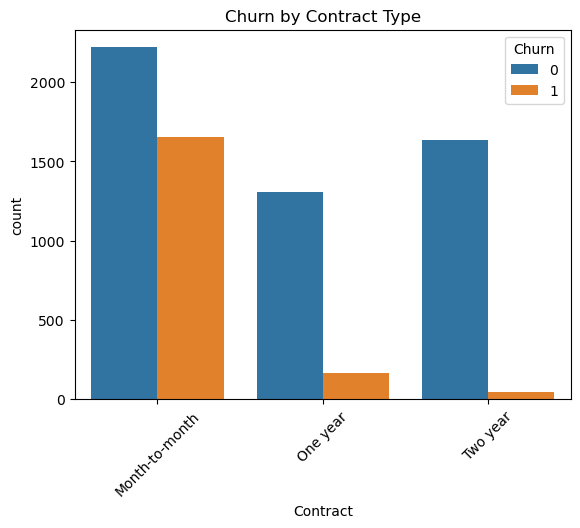

In [98]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Contract Type")
plt.show()

In [99]:
# Monthly Charges vs Churn

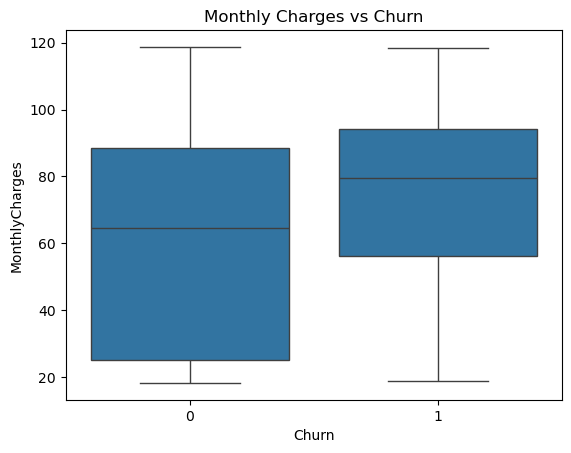

In [100]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Feature Engineering

In [101]:
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

Encoding Categorical Value

In [102]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

Split Data

In [103]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling 

In [104]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model 1 — Logistic Regression

In [105]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [106]:
y_pred_lr = lr.predict(X_test)

In [107]:
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



  Model 2 — Random Forest

In [108]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
y_pred_rf = rf.predict(X_test)

In [110]:
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.55       374

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



ROC-AUC Score

In [111]:
lr_probs = lr.predict_proba(X_test)[:,1]

In [112]:
rf_probs = rf.predict_proba(X_test)[:,1]

In [113]:
print("Logistic Regression AUC:", roc_auc_score(y_test, lr_probs))

Logistic Regression AUC: 0.8301686070890559


In [114]:
print("Random Forest AUC:", roc_auc_score(y_test, rf_probs))

Random Forest AUC: 0.8166236132752845


ROC Curve

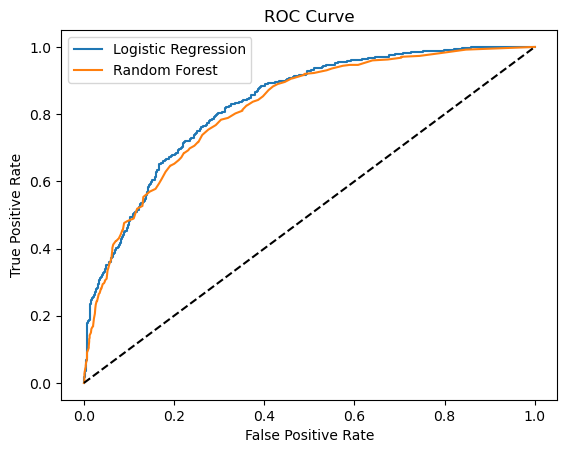

In [115]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

“ROC-AUC evaluates how well a model distinguishes between classes across all thresholds. In my churn project, I used it to compare models and ensure that the model could effectively identify high-risk customers while balancing false positives.”

Feature Importance (Random Forest)

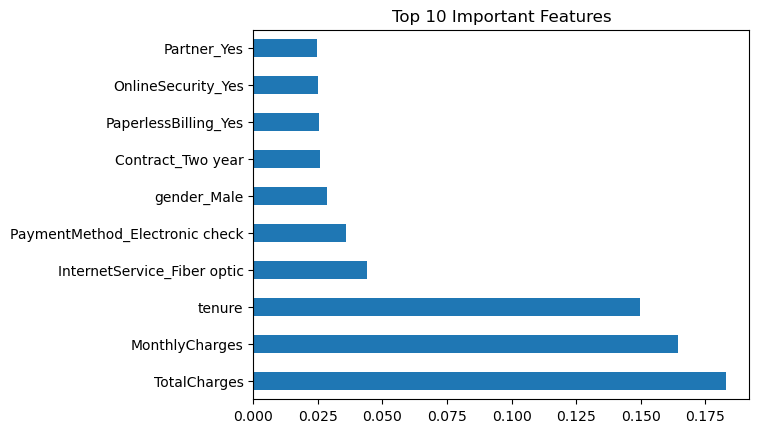

In [116]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

-> Business Insights

Key Insights:
- Month-to-month contracts have higher churn
- Customers with high monthly charges are more likely to churn
- Low tenure customers are at highest risk

Recommendations:
- Offer discounts for long-term contracts
- Improve onboarding for new users
- Provide flexible pricing plans